In [4]:
import numpy as np 
import umap 
import matplotlib.pyplot as plt 

In [5]:
def generate_2d_mesh(x_min=0, x_max=1, y_min=0, y_max=1, num_x=30, num_y=30):
    x = np.linspace(x_min, x_max, num_x)
    y = np.linspace(y_min, y_max, num_y)
    xx, yy = np.meshgrid(x, y)
    points = np.vstack([xx.ravel(), yy.ravel()]).T

    return points

def cost(x,I=None):
    k = len(x)
    if I is None:
        I = np.arange(k)        
    w = np.sort(np.random.dirichlet(np.ones(k),size=1))[0]
    w_ = np.empty_like(w)
    w_[I] = w
    dim_cost = []
    for i in range(k):
        ell = 1/(w_[i]+1)
        f_x_t = ell*np.exp(-(np.abs(x[i])*ell))
        dim_cost.append(1-f_x_t)
    return np.prod(np.array(dim_cost))   

def plot_contour(X, Z):
    x_unique = np.unique(X[:, 0])
    y_unique = np.unique(X[:, 1])
    X_grid = x_unique
    Y_grid = y_unique

    # Reshape Z to match mesh shape
    Z_grid = Z.reshape(len(y_unique), len(x_unique))  # Note: y first, x second due to row-major order

    # Create contour plot
    fig, ax = plt.subplots()
    contour = ax.contourf(X_grid, Y_grid, Z_grid, cmap='coolwarm')
    plt.colorbar(contour, label='Cost')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()

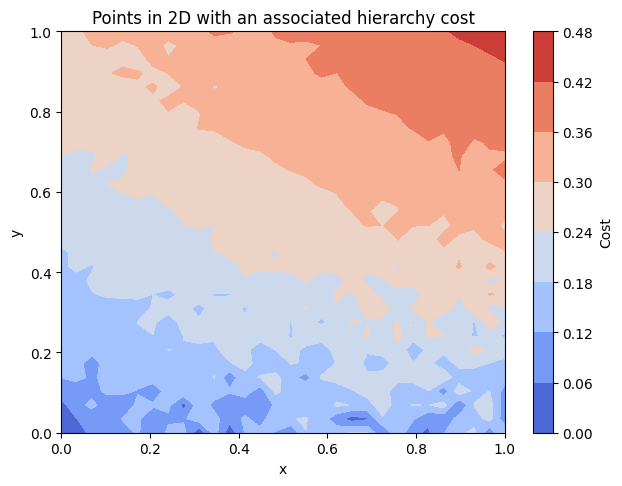

In [6]:
points = generate_2d_mesh(x_min=0, x_max=1, y_min=0, y_max=1)
cost_values = np.asarray([cost(p, I = [1,0]) for p in points])
plot_contour(points, cost_values)
plt.title('Points in 2D with an associated hierarchy cost')
plt.show()

/Users/kiran/Documents/codebase/envs/gabo/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


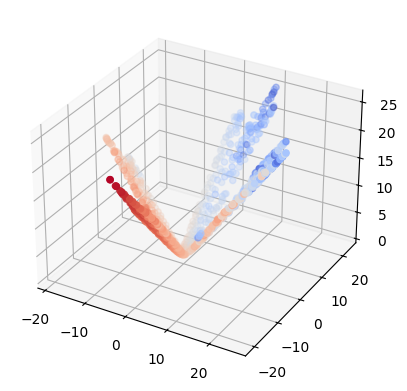

In [9]:
# UMAP Embedding 
mapper = umap.UMAP(output_metric='hyperboloid', random_state=42)
mapper.fit(points)
fig, ax = plt.subplots(subplot_kw= {"projection" : "3d"})
x = mapper.embedding_[:, 0]
y = mapper.embedding_[:, 1]
z = np.sqrt(1 + np.sum(mapper.embedding_**2, axis=1))
ax.scatter(x, y, z, c = cost_values, cmap='coolwarm')
plt.show()

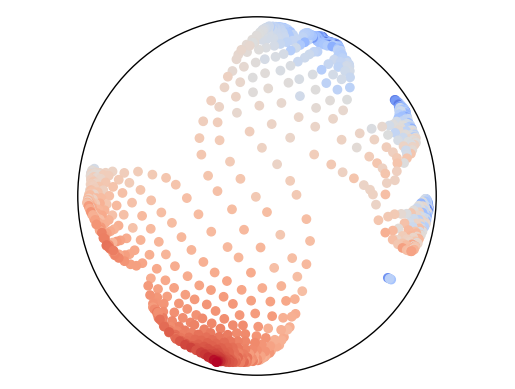

In [11]:
disk_x = x / (1 + z)
disk_y = y / (1 + z)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(disk_x, disk_y, c=cost_values, cmap="coolwarm")
boundary = plt.Circle((0,0), 1, fc='none', ec='k')
ax.add_artist(boundary)
ax.axis('off')
ax.axis('equal')
plt.show()